In [ ]:
import gc
import os
import time
import random
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sys import getsizeof
import tensorflow as tf
print(tf.__version__)
from tensorflow.keras import metrics
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, callbacks
from tensorflow.keras.models import Sequential, Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras import layers, models
from sklearn.preprocessing import LabelEncoder

! pip install tensorflow

2.20.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

dataSourcePath = '/content/drive/MyDrive/BIAI/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
X = np.load(dataSourcePath+"abc_Dane32PrzetworzoneAVGlog.npy")
y_txt = np.load(dataSourcePath+"abc_EtykietyDanychlog.npy", allow_pickle=True)

X = np.transpose(X, (0,2,3,1))
# Wymiary pojedynczego obrazu
input_shape = X.shape[1:]


In [ ]:
print(X.shape)
print(y_txt.shape)
print(input_shape)

(1265, 36, 301, 21)
(1265,)
(36, 301, 21)


In [ ]:
labelEnc = LabelEncoder()
y = labelEnc.fit_transform(y_txt)
l_klas = len(labelEnc.classes_)
print(labelEnc.classes_)

['abstract' 'airplane' 'apple' 'banana' 'bird' 'boat' 'car' 'dog' 'person'
 'train' 'zebra']


In [ ]:
# PODZIAŁ 40-40-20 - pies
#60-20-20 - jabłko
#72-18-10 - ptak
X_train_validate, X_test, y_train_validate, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_validate, y_train, y_validate = train_test_split(X_train_validate, y_train_validate, test_size=0.25, random_state=42)


In [ ]:
#Normalizacja - standaryzacja (Z-score)
srednia = np.mean(X_train, axis=(0,1,2), keepdims=True) # 0-epoka, 1-czestotliwosc, 2-czas <-Do usrednienia 3-kanal
std = np.std(X_train, axis=(0,1,2), keepdims=True )

print(srednia.shape)
print("Srednie dla 21 kanalow: \n")
print(srednia[0][0][0])

X_train= (X_train - srednia)/std
X_validate = (X_validate - srednia)/std
X_test = (X_test - srednia)/std

(1, 1, 1, 21)
Srednie dla 21 kanalow: 

[-93.468414 -93.99462  -94.36341  -94.511665 -94.39624  -93.959366
 -93.52934  -93.86797  -99.88352  -94.47009  -94.783615 -97.20687
 -94.32397  -93.542175 -93.7754   -95.2126   -94.79387  -99.88352
 -94.44243  -97.492455 -93.096596]


In [ ]:
model = models.Sequential()
model.add(layers.Conv2D(32, (1, 10), activation=None, padding='same', input_shape=input_shape))
model.add(layers.BatchNormalization())#  #
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D((2,2)))#   #
model.add(layers.Conv2D(64, (3,1), activation=None, padding='same'))
model.add(layers.BatchNormalization())#  #
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D((2,3)))
model.add(layers.Dropout(0.2)) # (anti-overfitting)
model.add(layers.DepthwiseConv2D(64, (3,3), activation=None, depth_multiplier=2, padding='same'))
model.add(layers.BatchNormalization())#  #
model.add(layers.Activation('relu'))
model.add(layers.DepthwiseConv2D(64, (2,2), activation=None, padding='same'))
model.add(layers.BatchNormalization())#  #
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D((2,2)))#   #

model.add(layers.Flatten())
#model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(128, activation=None))
  #model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.Dropout(0.3)) # (anti-overfitting)
model.add(layers.Dense(l_klas, activation='softmax'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(optimizer = optimizer , loss = 'sparse_categorical_crossentropy' ,
              metrics = ['accuracy'],#, metrics.Precision(), metrics.Recall(), metrics.AUC()],
              jit_compile=False)
model.summary()

ReduceLROnPlateau_callback = callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    patience = 5,
    verbose=1,
    factor=0.3,
    min_lr=0.0000001)

EarlyStopping_callback = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    start_from_epoch = 15,
    restore_best_weights=True,
    verbose=0,
    mode='min')

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_26 (Conv2D)              │ (None, 36, 301, 32)    │         6,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 36, 301, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_64 (Activation)      │ (None, 36, 301, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 18, 150, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 18, 150, 64)    │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 18, 150, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_65 (Activation)      │ (None, 18, 150, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 9, 50, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 9, 50, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_26             │ (None, 3, 17, 128)     │       524,416 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 3, 17, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_66 (Activation)      │ (None, 3, 17, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_27             │ (None, 2, 9, 128)      │       524,416 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 2, 9, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_67 (Activation)      │ (None, 2, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 1, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_68 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,130,283 (4.31 MB)

 Trainable params: 1,129,579 (4.31 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
epochs = 70
batch_size=32  #16 # im mniejsza, tym większa dokładność, ale i więcej czasu

print("Poczatek treningu")
hist = model.fit(
    x=X_train,
    y=y_train,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    callbacks=[ReduceLROnPlateau_callback, EarlyStopping_callback],
    #callbacks=[ReduceLROnPlateau_callback],
    validation_data=(X_validate, y_validate),
    shuffle=True
)


Poczatek treningu
Epoch 1/70
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 165ms/step - accuracy: 0.0909 - loss: 2.5133 - val_accuracy: 0.0870 - val_loss: 2.3974 - learning_rate: 0.0010
Epoch 2/70
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.1357 - loss: 2.3605 - val_accuracy: 0.0949 - val_loss: 2.3956 - learning_rate: 0.0010
Epoch 3/70
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.1713 - loss: 2.2925 - val_accuracy: 0.1344 - val_loss: 2.3933 - learning_rate: 0.0010
Epoch 4/70
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.1976 - loss: 2.2382 - val_accuracy: 0.1462 - val_loss: 2.3912 - learning_rate: 0.0010
Epoch 5/70
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.2398 - loss: 2.1478 - val_accuracy: 0.1423 - val_loss: 2.3846 - learning_rate: 0.0010
Epoch 6/70
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.2279 - loss: 2.1125 - val_accuracy: 0.1423 - val_loss: 2.3755 - learning_rate: 0.0010
Epoch 7/70
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.2859 - lo

In [ ]:

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Skuteczność na danych testowych: {test_acc*100:.2f}%")


Skuteczność na danych testowych: 22.53%


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
              precision    recall  f1-score   support

           0       0.33      0.62      0.43        24
           1       0.13      0.10      0.11        21
           2       0.09      0.12      0.10        26
           3       0.23      0.10      0.14        29
           4       0.23      0.24      0.24        25
           5       0.19      0.19      0.19        31
           6       0.10      0.12      0.11        16
           7       0.28      0.33      0.30        15
           8       0.58      0.39      0.47        28
           9       0.18      0.17      0.18        23
          10       0.00      0.00      0.00        15

    accuracy                           0.23       253
   macro avg       0.21      0.22      0.21       253
weighted avg       0.23      0.23      0.22       253



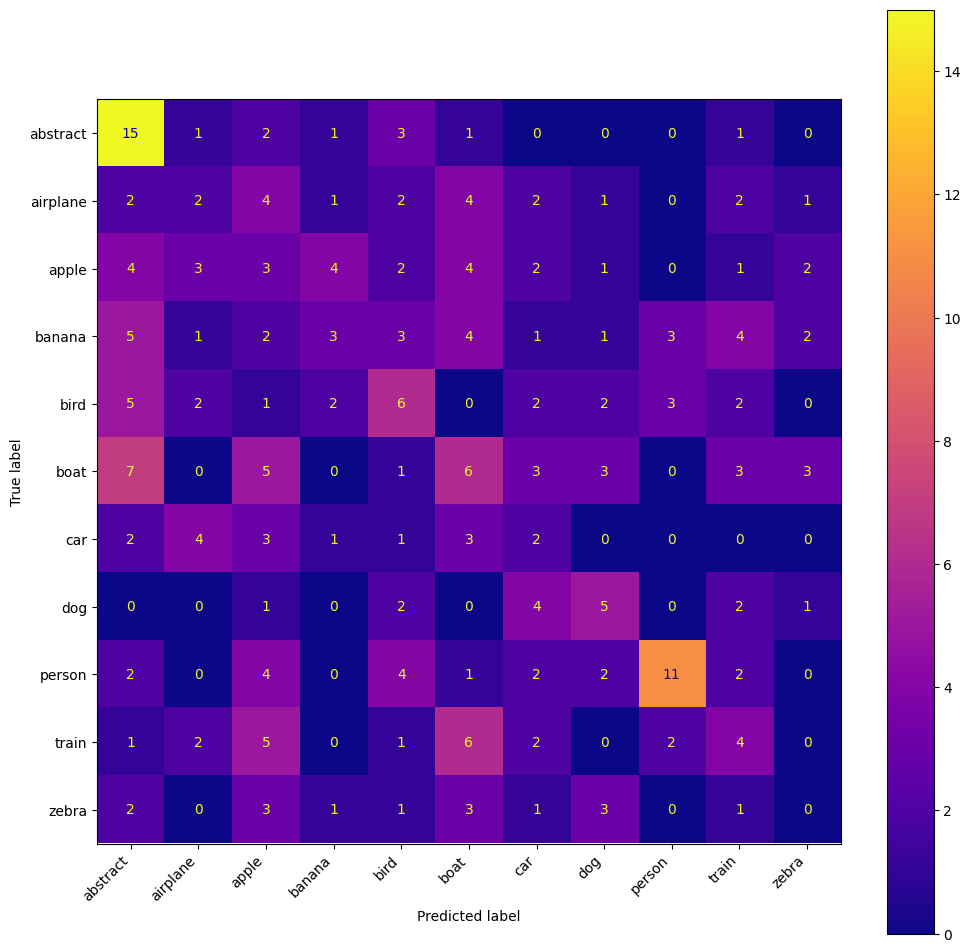

In [ ]:
y_predicted = model.predict(X_test)
y_p_argmax = np.argmax(y_predicted, axis=1)
#y_test_argmax = np.argmax(y_test.to_numpy(), axis=1)
categories=["abstract","airplane","apple","banana","bird","boat","car","dog","person","train","zebra"]

print(classification_report(y_test,y_p_argmax))
matrix = confusion_matrix(y_test, y_p_argmax)

disp = ConfusionMatrixDisplay(matrix, display_labels=categories)
fig, ax = plt.subplots(figsize=(12,12))
disp.plot(ax=ax, cmap="plasma") #viridis , plasma
plt.xticks(rotation=45, ha='right')
plt.show()
plt.close()

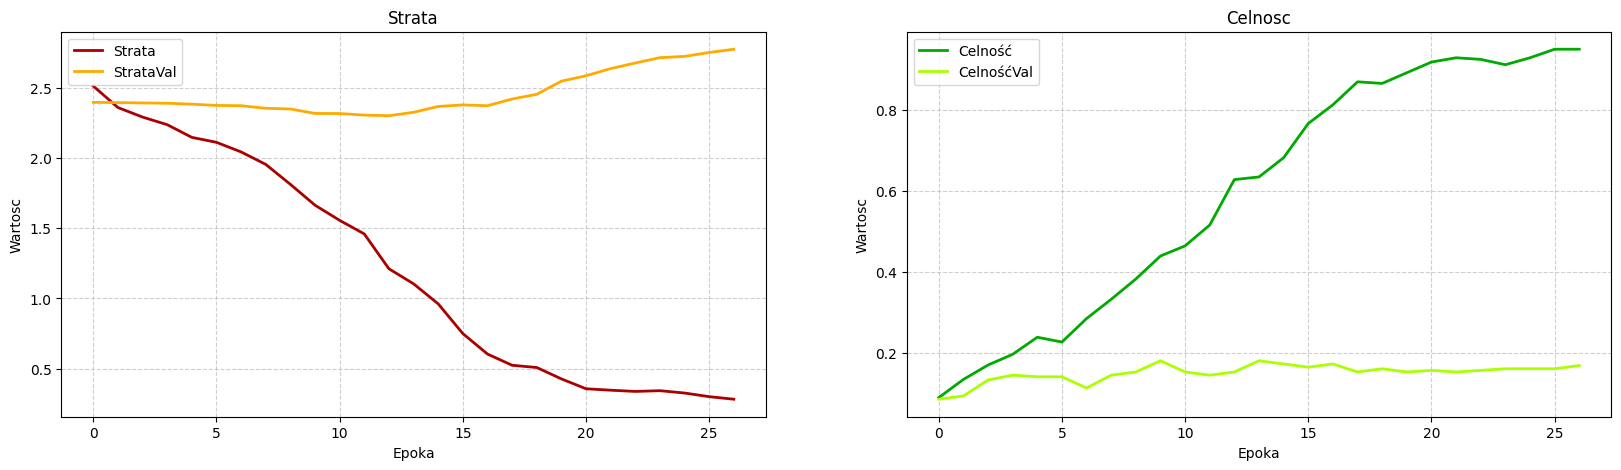

In [ ]:
wyk, (os1,os2) = plt.subplots(1,2, figsize=(20,5))
os1.plot(hist.history['loss'],label='Strata',color='#AA0000',linewidth=2)
os1.plot(hist.history['val_loss'],label='StrataVal',color='#FFAA00',linewidth=2)
os1.set_title('Strata')
os1.set_xlabel('Epoka',fontsize=10)
os1.set_ylabel('Wartosc',fontsize=10)
os1.grid(True,linestyle='--',alpha=0.6)
os1.legend(fontsize=10)

os2.plot(hist.history['accuracy'],label='Celność',color='#00AA00',linewidth=2)
os2.plot(hist.history['val_accuracy'],label='CelnośćVal',color='#AAFF00',linewidth=2)
os2.set_title('Celnosc')
os2.set_xlabel('Epoka',fontsize=10)
os2.set_ylabel('Wartosc',fontsize=10)
os2.grid(True,linestyle='--',alpha=0.6)
os2.legend(fontsize=10)

In [ ]:
model.save(dataSourcePath + "Najlepszy3-09-0_44" + ".keras")
#zaladowany = keras.models.load_model(dataSourcePath+nazwa+".keras")